<a href="https://colab.research.google.com/github/satyamlokhande25-maker/United-Nation-Global-Terrorism-Analysis-Using-ML-unsupervised-Learning-/blob/main/Nation_Global_Terrorism_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT NAME**

 United Nation Global Terrorism Analysis Using ML (unsupervised Learning)

# **OBJECTIVE**

The objective of applying k-Means Clustering in this project is to group similar terrorist incidents
based on casualty – related features such as the number of people killed (Nkill) wounded and
total casualties. This helps identify natural pattern in the dataset and categorize incidents into
different severity level without using predefined labels. The Clustering enable better
understanding of attack intensity by segmenting event into low, medium and high severity
groups.

# **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# **DATA LOADING**

In [ ]:
df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')

/tmp/ipykernel_2427/1314922678.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')


**UNDARSTAND DATA**

In [ ]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [ ]:
df.tail()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
181686,201712310022,2017,12,31,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Al-Shabaab Militants Attack Army Che...","""Highlights: Somalia Daily Media Highlights 2 ...","""Highlights: Somalia Daily Media Highlights 1 ...",START Primary Collection,0,0,0,0,NaN
181687,201712310029,2017,12,31,NaN,0,NaN,200,Syria,10,...,NaN,"""Putin's 'victory' in Syria has turned into a ...","""Two Russian soldiers killed at Hmeymim base i...","""Two Russian servicemen killed in Syria mortar...",START Primary Collection,-9,-9,1,1,NaN
181688,201712310030,2017,12,31,NaN,0,NaN,160,Philippines,5,...,NaN,"""Maguindanao clashes trap tribe members,"" Phil...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
181689,201712310031,2017,12,31,NaN,0,NaN,92,India,6,...,NaN,"""Trader escapes grenade attack in Imphal,"" Bus...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN
181690,201712310032,2017,12,31,NaN,0,NaN,160,Philippines,5,...,NaN,"""Security tightened in Cotabato following IED ...","""Security tightened in Cotabato City,"" Manila ...",NaN,START Primary Collection,-9,-9,0,-9,NaN


**SUMMARIZE THE DATASET**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


**SUMMARIZE THE NUMERICAL COLUMNS OF THE DATASET**

In [ ]:
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


# **DATA HANDLING**



In [ ]:
df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)

# **FEATURE ENGINEERING**

In [ ]:
df['total_casualties'] = df['nkill'] + df['nwound']

X = df[['nkill','nwound','total_casualties']]

In [ ]:
print(X)

        nkill  nwound  total_casualties
0         1.0     0.0               1.0
1         0.0     0.0               0.0
2         1.0     0.0               1.0
3         0.0     0.0               0.0
4         0.0     0.0               0.0
...       ...     ...               ...
181686    1.0     2.0               3.0
181687    2.0     7.0               9.0
181688    0.0     0.0               0.0
181689    0.0     0.0               0.0
181690    0.0     0.0               0.0

[181691 rows x 3 columns]


# **STANDARD SCALING**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print("NORMALIZATION_VALUE",X_scaled)

NORMALIZATION_VALUE [[-0.11284018 -0.08403747 -0.10233325]
 [-0.20191096 -0.08403747 -0.12699093]
 [-0.11284018 -0.08403747 -0.10233325]
 ...
 [-0.20191096 -0.08403747 -0.12699093]
 [-0.20191096 -0.08403747 -0.12699093]
 [-0.20191096 -0.08403747 -0.12699093]]


# **MODEL TRAINING PHASE USING KMEANS CLUSTERING**

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print(df['cluster'])

0         0
1         0
2         0
3         0
4         0
         ..
181686    0
181687    0
181688    0
181689    0
181690    0
Name: cluster, Length: 181691, dtype: int32


# **KMEANS CLUSTER GRAPH**

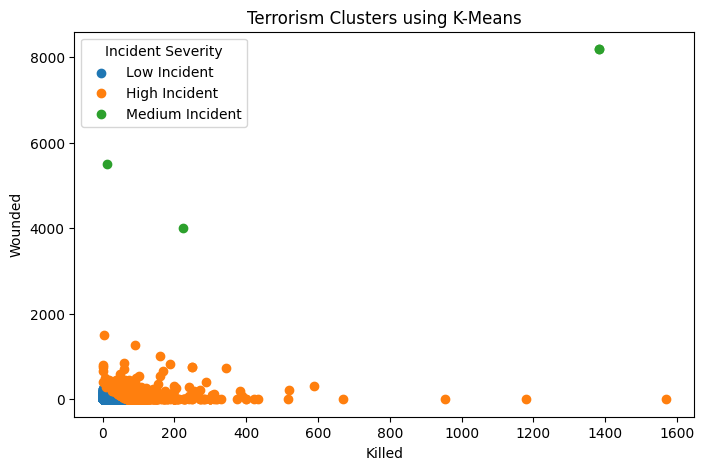

In [ ]:
plt.figure(figsize=(8,5))


labels = {
    0: "Low Incident",
    1: "Medium Incident",
    2: "High Incident"
}

for cluster in df['cluster'].unique():
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['nkill'],
                subset['nwound'],
                label=labels[cluster])

plt.xlabel("Killed")
plt.ylabel("Wounded")
plt.title("Terrorism Clusters using K-Means")
plt.legend(title="Incident Severity")

plt.show()

# **INSIGHT**

• The K-Means algorithm grouped terrorist incidents into three distinct clusters based on
casualties.   
• The low severity cluster contains incidents with minimal killed and wounded values.   
• The medium severity cluster represents attacks with moderate casualties.   
• The high severity cluster includes incidents with large numbers of killed and wounded,
indicating high-impact attacks.   
• Most incidents fall into the low severity cluster, showing that high-casualty attacks are
relatively rare.   
• The clustering reveals natural segmentation of incidents based on impact level.   

# **K-Means Evaluation Metrics**

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [ ]:
# labels
labels = df['cluster']

In [ ]:
# scores
sil = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
print("Silhouette Score:", sil)
print("Davies Bouldin Score:", db)
print("Calinski Harabasz Score:", ch)


Silhouette Score: 0.9642484095847615
Davies Bouldin Score: 0.5876978478755398
Calinski Harabasz Score: 181691.45550329977


**EVALUTION METRIC SCORE GRAPH**

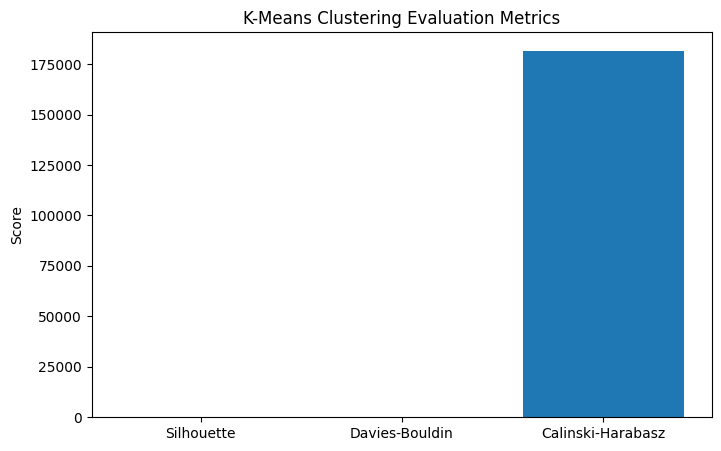

In [ ]:

scores = [sil, db, ch]
names = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']

plt.figure(figsize=(8,5))
plt.bar(names, scores)
plt.title("K-Means Clustering Evaluation Metrics")
plt.ylabel("Score")
plt.show()

**K-Means Clustering Evaluation — Metrics Explanation**



*   The Silhouette Score obtained is 0.9642, which is very close to 1. This indicates that the clusters are highly well-separated and the data points are clearly assigned to their respective clusters with minimal overlap.

*   The Davies–Bouldin Score obtained is 0.5877, which is relatively low. This suggests that the clusters are compact and sufficiently separated from each other, indicating good clustering performance.

*   The Calinski–Harabasz Score obtained is 181691.46, which is very high. A higher value indicates better separation between clusters and strong cluster structure in the dataset.

*   These evaluation metrics collectively indicate that the K-Means algorithm has produced well-defined, compact, and clearly separated clusters.

*  Overall, the clustering model performs very well and successfully groups terrorist incidents







# **CONCLUSION**

K-Means clustering successfully identified hidden patterns in the dataset by grouping
terrorist incidents into low, medium, and high severity categories. This segmentation
helps in understanding attack intensity and highlights rare but high-impact incidents. The
results demonstrate that unsupervised learning can effectively categorize events and
support better analysis of terrorism trends.\

The clustering results showed clear separation between severity levels, indicating meaningful grouping of terrorist incidents. The model performance was evaluated using Silhouette Score (0.9642), Davies–Bouldin Score (0.5877), and Calinski–Harabasz Score (181691.46). The high Silhouette score, low Davies–Bouldin score, and high Calinski–Harabasz score confirm that the clusters are compact and well-separated.

Overall, the unsupervised learning approach successfully discovered natural groupings in the dataset and helped categorize terrorist incidents based on severity and impact.